<a href="https://colab.research.google.com/github/NathalieKa/Python101/blob/main/Ziffernerkennung_OVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

# Ziffernerkennung mit Logistischer Regression

Die Klassifikation handgeschriebener Ziffern ist eine der klassischen Aufgaben des maschinellen Lernens und bildete in den 1990er Jahren den Ausgangspunkt für große Durchbrüche im Bereich der neuronalen Netze.

Einer der Pioniere auf diesem Gebiet war **Yann LeCun**, der die sogenannte **LeNet-5 Architektur** entwickelte. Sie wurde unter anderem von Banken wie der amerikanischen Postbank (USPS) zur automatischen Erkennung von Ziffern auf Schecks eingesetzt – eines der ersten produktiven Einsatzszenarien für neuronale Netze und insbesondere für **Convolutional Neural Networks (CNNs)**.

Im Jahr 1998 wurde das berühmte Paper "Gradient-based learning applied to document recognition" veröffentlicht, das bis heute als Meilenstein gilt.

Auch wenn wir in diesem Praktikum (noch) keine CNNs einsetzen, können wir die Ziffernerkennung mit klassischer Logistischer Regression als Übungsbeispiel verwenden. Dabei beschränken wir uns zunächst auf zwei Klassen (z. B. Ziffern `0` und `1`) und führen anschließend eine **Multiklassenklassifikation** durch.

Mehr dazu:
- Yann LeCun: [http://yann.lecun.com/exdb/lenet/](http://yann.lecun.com/exdb/lenet/)
- Paper: [LeNet 1998 PDF](http://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf)

Im folgenden Beispiel laden wir einen Datensatz, in dem handschriftliche Ziffern mit einer Auflösung von 8x8 Pixeln als Graustufenbilder abgelegt sind. Die Pixel sind dabei als eindimensionales Array gespeichert und daher vor dem Anzeigen in ein 8x8 Array umgeformt werden.

Zunächst führen wir eine binäre Klassifikation durch. Dazu laden wir nur die Bilder der Nullen und Einsen in unseren Datensatz `X` (Pixel) und `y` (Label).


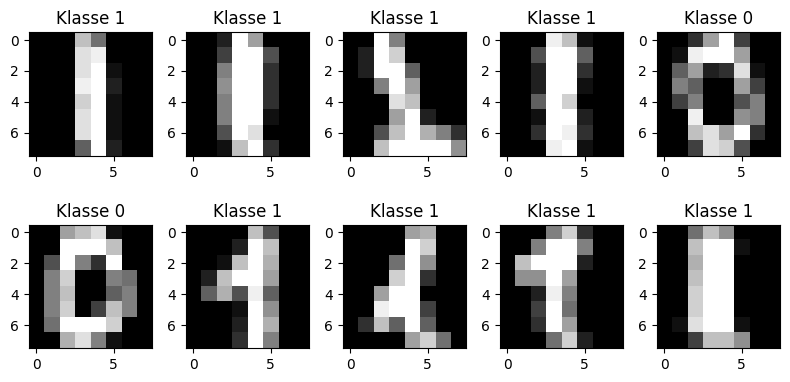

In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from random import randint
import numpy as np

digits = load_digits(as_frame=True).frame #load_digits(...) lädt den Datensatz mit handgeschriebenen Ziffern. /as_frame=True : Gib mir das als Tabelle (DataFrame).
#In digits steckt jetzt eine Tabelle mit allen Ziffern 0–9. Jede Zeile = ein Bild, mit 64 Pixel-Spalten plus einer Spalte target für das Label.

digits = digits[np.logical_or(digits.target == 0, digits.target == 1)]
#digits.target == 0 → ergibt für jede Zeile True, wenn das Label 0 ist. /digits.target == 1 → dasselbe für Label 1.
#np.logical_or(...) → True, wenn eins von beiden zutrifft.
# digits[...] → filtert die Tabelle: behält nur die Zeilen, wo das Ergebnis True ist.


X = digits.drop("target", axis=1).values #digits.drop("target", axis=1) → entfernt die Spalte target (axis=1 bedeutet "Spalte").
#.values → wandelt die Tabelle in ein reines Zahlen-Array um.
#X enthält jetzt nur noch die Pixel – die Eingabedaten für das Modell.

y = digits.target.values
#Nimmt nur die Spalte target und wandelt sie in ein Array.
#y enthält die Labels (also 0 oder 1) – die richtigen Antworten.


def plot_digits(X,y):
    fig, axes = plt.subplots(2, 5, figsize=(8,4))
    for i in range(10):
        idx = randint(0,X.shape[0]-1)
        ax = axes[i//5, i%5]
        ax.imshow(X[idx].reshape(8,8), cmap='gray')
        ax.set_title(f'Klasse {y[idx]}')
    plt.tight_layout()

plot_digits(X,y)




---

Die Bilder – was steckt drin?

Stell dir winzige Bilder vor: nur 8×8 Pixel groß (also insgesamt 64 Pixel pro Bild). Jedes Pixel ist ein Graustufenwert – also eine Zahl, die sagt: "Wie hell oder dunkel ist dieser Punkt?" Je größer die Zahl, desto heller (oder dunkler, je nach Konvention) der Pixel.

Wichtig: Die 64 Pixel sind nicht als 8×8-Quadrat gespeichert, sondern als lange Reihe von 64 Zahlen hintereinander. Wenn man das Bild anzeigen will, muss man es erst wieder in die 8×8-Form "zurückfalten".



---



Wie immer teilen wir auch hier den Datensatz auf, um Testdaten vorzubehalten.

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Nun wenden wir die Logistische Regression an, um die Ziffen zu klassifizieren. Die `score`-Methode liefert uns die *Accuracy*.

In [3]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X_train, y_train)
model.score(X_test, y_test) *100

100.0

**Aufgabe: Führen Sie die Klassikation nun erneut durch, aber mit den Ziffern 1 und 8. Ist das Ergebnis immer noch so gut?**

95.32710280373831

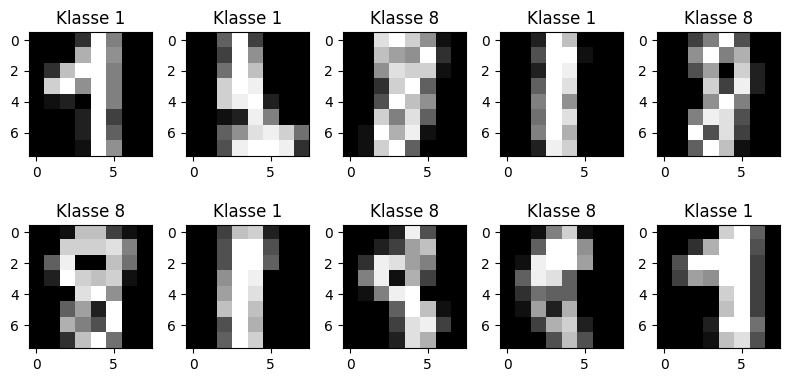

In [4]:
digits = load_digits(as_frame=True).frame
digits = digits[np.logical_or(digits.target == 8, digits.target == 1)]

X = digits.drop("target", axis=1).values
y = digits.target.values
plot_digits(X,y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression().fit(X_train, y_train)
model.score(X_test, y_test) *100

**Aufgabe: Führen Sie nun eine Multiklassen-Klassikation für die Ziffern von 0 bis 9 durch und berechnen Sie die Accuracy.**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


96.48148148148148

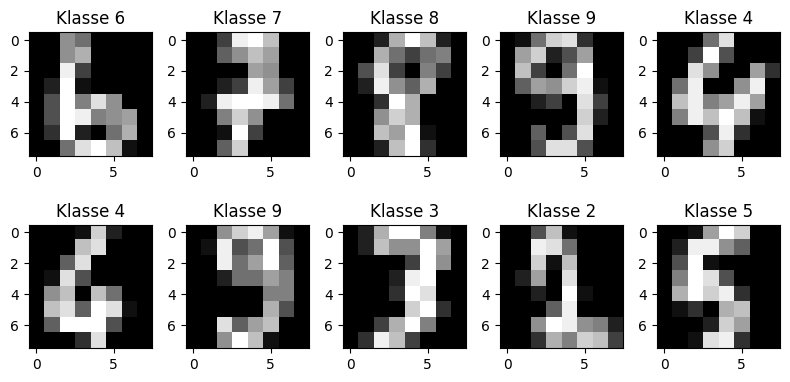

In [5]:
digits = load_digits(as_frame=True).frame

X = digits.drop("target", axis=1).values
y = digits.target.values
plot_digits(X,y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression().fit(X_train, y_train)
model.score(X_test, y_test) *100

**Aufgabe: Geben Sie die Konfusionsmatrix für das Multiklassen-Modell mit der Funktion `confusion_matrix` aus `sklearn.metrics`` aus.**

In [6]:
from sklearn.metrics import confusion_matrix


y_pred = model.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[53,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 47,  1,  0,  0,  0,  0,  0,  2,  0],
       [ 0,  1, 46,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1, 52,  0,  1,  0,  0,  0,  0],
       [ 0,  1,  0,  0, 58,  0,  1,  0,  0,  0],
       [ 0,  1,  0,  0,  0, 62,  1,  1,  0,  1],
       [ 0,  0,  0,  0,  0,  1, 52,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0, 53,  0,  1],
       [ 0,  0,  0,  0,  0,  1,  0,  0, 42,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  2, 56]])

Die Funktion `confusion_matrix` aus `sklearn.metrics` ist sehr nützlich, wenn Sie sich einen Überblick über die Vorhersagequalität Ihres Modells verschaffen möchten – insbesondere bei **Multiklassen-Klassifikation**.

Allerdings ist die Standardausgabe der Funktion **nur eine rohe Zahlenmatrix** – korrekt, aber **nicht sehr übersichtlich**.

Wenn man die Konfusionsmatrix **ansprechend visualisieren** möchte, kann man zusätzliche Bibliotheken wie **`matplotlib`** oder **`seaborn`** verwenden. Damit lässt sich die Matrix als **grafische Darstellung mit Farben, Zahlenwerten und Achsenbeschriftungen** anzeigen.

Unten sehen Sie ein Beispiel für eine übersichtliche grafische Ausgabe mit `matplotlib`, die sich besonders gut eignet, um Fehlerklassen zu analysieren oder im Unterricht zu präsentieren.

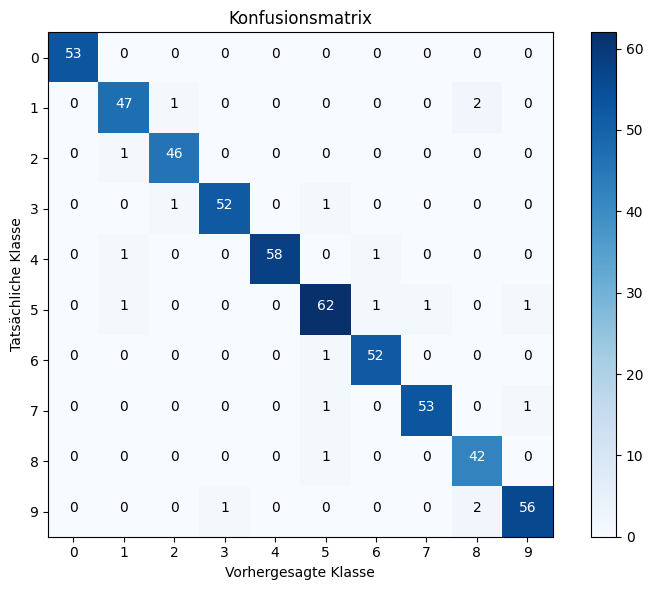

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Vorhersagen erzeugen
y_pred = model.predict(X_test)

# Konfusionsmatrix berechnen
cm = confusion_matrix(y_test, y_pred)

# Visualisierung mit matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Konfusionsmatrix")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

plt.ylabel('Tatsächliche Klasse')
plt.xlabel('Vorhergesagte Klasse')

# Werte eintragen
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

Die Diagonale (dunkelblau)
Das sind die richtigen Vorhersagen. Beispiele:

* 53 echte Nullen wurden auch als 0 erkannt ✅

* 47 echte Einsen wurden als 1 erkannt ✅

* 62 echte Fünfen wurden als 5 erkannt ✅

Alles außerhalb der Diagonale = Fehler
Beispiele aus deiner Matrix:

* 1 → 8 (2 mal): Zwei Einsen als Achten erkannt

* 9 → 8 (2 mal): Zwei Neunen als Achten erkannt

* 2 → 1 (1 mal): Eine Zwei als Eins erkannt